# ESTRUCTURA DE RAG

En esta entrega vamos a trabajar sobre una arquitectura que conceptualmente es la misma que se utiliza en modelos en producción, las etapas , las llamadas, y las tecnicas son basicamente las mismas, el unico cambio que vamos a tener es que no vamos a utilizar soluciones enlatadas para esto sino que vamos a desarrollar todo en un entorno casero, poco eficiente, pero super claro.

La intención es que podamos seguir estos pasos desde lo conceptual hasta lo practico para tener nuestro motor basico de consulta tipo RAG, pudiendo correr 100% local si asi lo queremos.


>Texto plano
 → Embeddings
 → Almacenamiento (JSON)
 → Query → embedding
 → Cosine similarity
 → Top N resultados
 → Prompt
 → LLM (Groq)



## Base de Conocimiento

Para nuestro caso particular vamos a trabajar con un texto plano (de donde proviene o como podemos transformar distintos tipos de documentos en ese texto plano lo dejamos para otra oportunidad).

La base de conocimiento es toda la información que entendemos que no formo parte del entrenamiento del modelo, los registros de una empresa, una columna de un csv, libros, correos electronicos, chats, etc.

La base de conocimiento son datos que el modelo no puede conocer si no se lo decimos nosotros.

Pero no todo dato suelto se puede ingerir como parte de la base de conocimiento , mejor dicho, todo dato se puede sumar, pero para eso necesita que le demos contexto para que el modelo pueda interpretar ese dato dentro de la consulta.

Si esperamos poner un csv con tres Columnas

Juan | 24 | 30  
Carlos | 20 | 32

Le hacemos la consulta al modelo
>" Quiero que me digas quien es mas joven, usa el siguiente contexto

 >contexto =

>Juan | 24 | 30  
>Carlos | 20 | 32 "

El modelo no va a tener idea de cual columna hace referencia a la edad, y podria ser peor, tal vez ninguna de esas columnas es la edad y el modelo va a asumir que uno de esos valores es la edad cuando no lo es.

Entonces lo primero que tenemos que pensar es ¿Que información es relevante para responder las preguntas que puedo hacer al modelo? ¿En que forma debo formatear los datos para mejorar la "comprensión" o "entendimiento" del modelo de los datos que le estoy dando?

> *Claramente si le ubieramos dado en el prompt un Ejemplo de como interpretar los datos el modelo podria resolver sin dudas el problema, pero con datos mas ambiguos o consultas mas complejas este problema se vuelve mas dificil de resolver solo con ejemplos.*


Volvamos a la definición de la base de conocimiento

###  ¿De qué está compuesta? (Tipos de Datos)

Una base de conocimientos en producción no discrimina formatos; puede ingerir e integrar información proveniente de múltiples fuentes:

1. **Documentos No Estructurados:** Archivos PDF, manuales de usuario, contratos legales, políticas de la empresa en Word, o minutas de reuniones en texto plano.
2. **Datos Semi-estructurados:** Archivos de configuración JSON, tablas HTML, publicaciones de blogs, o preguntas frecuentes (FAQs).
3. **Datos Estructurados:** Bases de datos relacionales (SQL), archivos CSV de reportería, o registros de auditoría (logs).

---

Como todo en la vida, mas estructurado, mas claro, las reglas mejor definidas y por ende menor posibilidad de error o alucinación, pero la magia del RAG reside en poder trabajar con todos los formatos y poder unir, para su anialisis, en una misma consulta datos estructurados con no estructurados.


###  El Flujo de Transformación: De Archivo a Base de Conocimientos

Para que un sistema RAG pueda buscar eficientemente dentro de la base de conocimientos, la información debe atravesar un proceso de **ingesta y preparación (Data Pipeline)**:



1. **Carga (Loading):** Se extrae el texto limpio de los archivos originales (eliminando imágenes innecesarias, formatos raros o metadatos rotos).
2. **Fragmentación (Chunking):** Los documentos largos se cortan en pedazos o "bloques" más chicos (por ejemplo, párrafos de 500 caracteres). Esto se hace porque los modelos tienen un límite de contexto y porque es más fácil encontrar respuestas precisas en fragmentos cortos.
3. **Indexación (Indexing):** Esos fragmentos se transforman (usando los embeddings que programamos antes) y se guardan en un motor de búsqueda organizado, que puede ser un índice de texto plano, una base de datos relacional (SQL) o una base de datos vectorial.



Como nuestra idea hoy es trabajar con un texto plano vamos a revisar las condiciones, y buenas practicas, para armar una base de conocimiento en este formato:

1. Estructura Jerárquica Clara (Uso de Markdown)
Aunque sea texto plano, utilizar la sintaxis de Markdown (#, ##, ###) es de utilidad. Muchos cargadores de documentos (como los de LangChain o LlamaIndex) pueden programarse para romper los fragmentos basándose en los encabezados (MarkdownHeaderTextSplitter).

>Regla: Cada sección debe ser atómica (tratar un solo tema).

>Mal ejemplo: Un único párrafo gigante que mezcle la política de devoluciones, los tiempos de envío y los costos.


```
   # Política de Devoluciones
   El cliente tiene un plazo de 30 días para devolver el producto...

   # Costos de Envío
   Los envíos dentro de la región son gratuitos...
```

Como se puede ver en el ejemplo, si bien el texto no esta estructurado en el estricto sentido de la palabra,si tiene una logica que el modelo puede utilizar para romper en secciones, y cada sección conserva una logica que permite al modelo responder de forma coherente.


2. Inyección de Contexto en cada Párrafo (Evitar Pronombres)
Una persona lee un documento de arriba hacia abajo y retiene el hilo conductor (en palabras del LLM tenemos un contexto muy largo que no podemos ir pausando o seleccionando ignorar). En cambio, si el sistema de recuperación RAG extrae un párrafo suelto del medio del archivo. Si ese párrafo usa pronombres o referencias ambiguas, el embedding perderá su significado semántico.

>Mal ejemplo: "Esta herramienta permite realizar análisis de datos ***.*** Fue desarrollada en 2024 y su principal ventaja es la velocidad." *(Si el RAG recupera solo la segunda oración, la IA no sabrá qué fue desarrollado en 2024 ni qué tiene velocidad).*

>Buen ejemplo: "La herramienta DataX permite realizar análisis de datos. DataX fue desarrollada en 2024 y la principal ventaja de DataX es la velocidad."

Como podemos ver cada oración (futuro chunk de información) mantiene un registro de forma independiente de que es lo que esta hablando.


Vamos con otros casos mas especificos para tener en cuenta

- Formato Estándar para Preguntas Frecuentes (FAQs)

>Si la base de conocimientos incluye respuestas a preguntas comunes, el formato debe ser ultra consistente para que el Producto Punto o la Similitud Coseno se alineen perfectamente con las dudas de los usuarios.

>Buenas prácticas de formato:

>Usar un prefijo claro como Pregunta: y Respuesta:.

>Mantener una sola línea de separación entre el par de pregunta y respuesta (un solo salto de linea).

- Manejo de Listas y Viñetas

>Las listas un recurso claro para las personas, pero se rompen facilmente al armar los embeddings si se cortan a la mitad durante el proceso de chunking o si el formato tiene diferencias que no se contemplan.

>Lo ideal: Cada elemento de la lista debe contener el sujeto principal, o bien la lista debe ser lo suficientemente corta para entrar completa en un solo bloque (chunk).

>Mal ejemplo:

Requisitos para la inscripción:
- Ser mayor de 18 años.
- Presentar DNI.


>Buen ejemplo:

- Para la inscripción es requisito ser mayor de 18 años.
- Para la inscripción es requisito presentar el DNI original.


El texto en ambos ejemplos contiene la misma información, pero si pensamos en los posibles chunks que podemos generar, algunos podrian perder sentido del contexto del parrafo donde se encuentra.

- Delimitadores de Datos y Metadatos

Cuando la estructura de los datos lleva a una mezcla de diferentes tipos de información en un mismo archivo de texto plano, se pueden usar delimitadores  (como ---) y sirve sumar metadatos al principio de cada sección. Esto ayuda tanto a los scripts de limpieza como al modelo a entender dónde termina un concepto y empieza otro.


Ejemplo con metadatos embebidos:

```

---
ID: DOC-042
Categoría: Soporte Técnico
Producto: Router AC1200
---
Si la luz roja del Router AC1200 parpadea, significa que no hay conexión a internet...
```


- Limpieza y Normalización del Archivo

>Antes de pasar el texto plano por el modelo de embedding es importante realizar controles como:

>Cero líneas en blanco excesivas: Sacar saltos de línea triples o cuádruples que arruinen el cálculo del tamaño del chunk.

>Codificación UTF-8: El archivo tiene que estar guardado estrictamente en UTF-8 para evitar que los acentos o caracteres como la ñ se transformen en símbolos raros (fffd o Ã±), lo que destruiría el embedding de esa palabra.

>Eliminar abreviaturas ambiguas: Reemplazá izq. por izquierda, tel. por teléfono, etc., para estandarizar el vocabulario conceptual.





### División o chunking

# Chunking: División Estratégica y Logica de Datos

¿Por qué no podemos meterle un PDF de 200 páginas entero al modelo de embeddings? Por tres razones fundamentales:
1. **Límites de Contexto:** Los modelos tienen un tope de tokens que pueden procesar a la vez.

2. **Dilución Semántica:** Si un vector representa a un libro entero, ese vector se vuelve un "promedio de todo" y pierde precisión. Es mucho más fácil encontrar una respuesta exacta si el vector apunta a un párrafo específico.
En la escuela nos enseñan a usar resumenes para que nuestro foco este sobre lo importante y no sobre todo.

3. **Costo y Velocidad:** Procesar fragmentos chicos es drásticamente más rápido y económico.

---

##  TOP 5 Estrategias de Chunking Más Utilizadas

Existen diferentes técnicas según la complejidad del documento:

### 1. Chunking de Tamaño Fijo (Fixed-size Chunking)
Es el método más primitivo. Definimos una cantidad de caracteres o tokens por bloque (por ejemplo, bloques de 500 caracteres).
* **El peligro:** Puede cortar una palabra o una frase importante exactamente a la mitad, destruyendo el significado.

### 2. Chunking con Solapamiento (Overlap Chunking)
Es la evolución del método anterior y el **estándar de la industria**. Mantiene el tamaño fijo, pero hace que el inicio de cada bloque comparta las últimas palabras del bloque anterior (un "overlap" o solapamiento).


* **¿Para qué sirve?** Funciona para dar cierta continuidad semantica. Asegura que el contexto que quedó colgado al final de un fragmento no se pierda y se arrastre al siguiente. Un solapamiento común es del 10% al 20% del tamaño del chunk (ej: Tamaño: 500, Solapamiento: 50).

### 3. Chunking Recursivo o Estructural
Es el enfoque más inteligente. Intenta cortar el texto respetando la estructura humana. Primero busca separar por párrafos (`\n\n`), si el párrafo sigue siendo muy grande busca separar por oraciones (`. `), y si aun así no entra, separa por espacios (` `).

### 4. Chunking con delimitadores
Si tenemos a disposición algun caracter, grupo de caracteres, palabras claves, que sirvan de señal de inicio y fin de una sección de información, podemos usar esto como fraccionador de chunks, un ejemplo simple seria una Ley, esta dividido por Articulos y subdividido en algunos casos por incisos, si usamos ARTICULO como delimitador podemos separar cada unidad de información.

###5. Chunking Hibrido
Normalmente hay que encarar mas de una tecnica para resolver nuestra necediad, por ejemplo un chunking con delimitadores nos puede devolver secciones muy grandes que deben ser subdivididas,  para esto podemos sumarle un chunking con solapamiento o algun otra tecnica que sea adecuada para nuestro caso.



[02_CHUNKING](https://colab.research.google.com/drive/1t995vBUntb2g9Jt7U6I5kFguLFcKukWK?usp=sharing)


 # ALMACENAMIENTO (JSON)

 Las etapas que le siguen a la definición de la base de conocimiento es:

 > Embeddings
 → Almacenamiento (JSON)

 Ya vimos una intro sobre embeddings en la clase anterior, por lo que podemos considerar que ya sabemos como llevamos una serie de textos segmentados en embeddings.

 Pasamos directamente a,
 > ¿Que hacer con los embeddings y los datos de la base de conocimiento?



 En un esquema de producción todos los datos se vuelcan en una estructura de datos que permita una busqueda de datos rapida, para nuestra etapa de aprendizaje vamos a usar un sistema simplificado como una estructura json.

Como no vamos a dejar nada por sentado definimos JSON:
JSON (JavaScript Object Notation) es un formato ligero de texto utilizado para almacenar e intercambiar datos estructurados entre diferentes sistemas, aplicaciones o servidores. Es el estándar principal utilizado hoy en día por su facilidad de lectura tanto para humanos como para máquinas


Partes y elementos que lo conforman

- Objetos ( {} ): Colecciones de datos que se encierran entre llaves. Contienen pares de "clave/valor", son la UNIDAD.

- Claves (Key): El nombre o identificador del dato. Siempre debe ir escrito entre comillas dobles (por ejemplo, "nombre").

- Valores (Value): El dato en sí mismo. Se relaciona con la clave mediante dos puntos : (por ejemplo, "nombre": "Juan"). Pueden ser:

> -Cadenas de texto: Entre comillas dobles (ej. "Argentina").

> -Números: Enteros o decimales, sin comillas (ej. 26, 3.14).

> -Booleanos: Valores lógicos true (verdadero) o false (falso) sin comillas.

> -Arreglos ( [] ): Listas de elementos separados por comas. Un arreglo puede contener textos, números u otros objetos (ej. [1, 2, 3]).

> Nulo (null): Representa la ausencia de valor.

> Comas ( , ): Se usan para separar múltiples pares clave-valor dentro de un objeto o elementos dentro de un arreglo.
-----------


Veamos una estructura minima de un arrego JSON para nuestra finalidad:

In [ ]:
# Tenemos una lista (en este caso de un solo elemento) de dos claves/valor
# Texto original (resultado del proceso de chunking)
# embedding que es el resultado del proceso de pasar el texto original por un modelo de embedding

base = [
    {
        "texto": "...",
        "embedding": [...]
    }
]


Pensemos hasta aqui cual puede ser su utilidad.

Tenemos una lista de objetos que tienen almacenado como información un texto y la versión de embeddings del mismo texto.

Con esto seria facil y rapido poder buscar el embedding de un texto, o tambien a travez de un embedding buscar un texto. Basicamente tenemos un diccionario bidireccional que nos permite trabajar indistintamente con los dos dominios

Ya dijimos antes que hay tecnicas matematicas que podemos aplicar a los embeddings (vectores con numeros que representan caracteristicas de las palabras) para poder trabajar con el texto como si fueran matrices, para nuestro interes particular...medir cercanias entre oraciones, medirlas desde la semantica, es decir desde la intencionalidad de las oraciones.

¿Que podriamos hacer entonces?

Imaginemos que tenemos poblada la lista base con 1.000 objetos json con el chunk de texto y el embedding que lo define. De una forma arcaica se nos puede ocurrir comparar esta lista de objetos con otro texto para ver si hablan de lo mismo, es decir si tienen la misma intencionalidad.

Para esto el flujo de trabajo pasaria a ser:

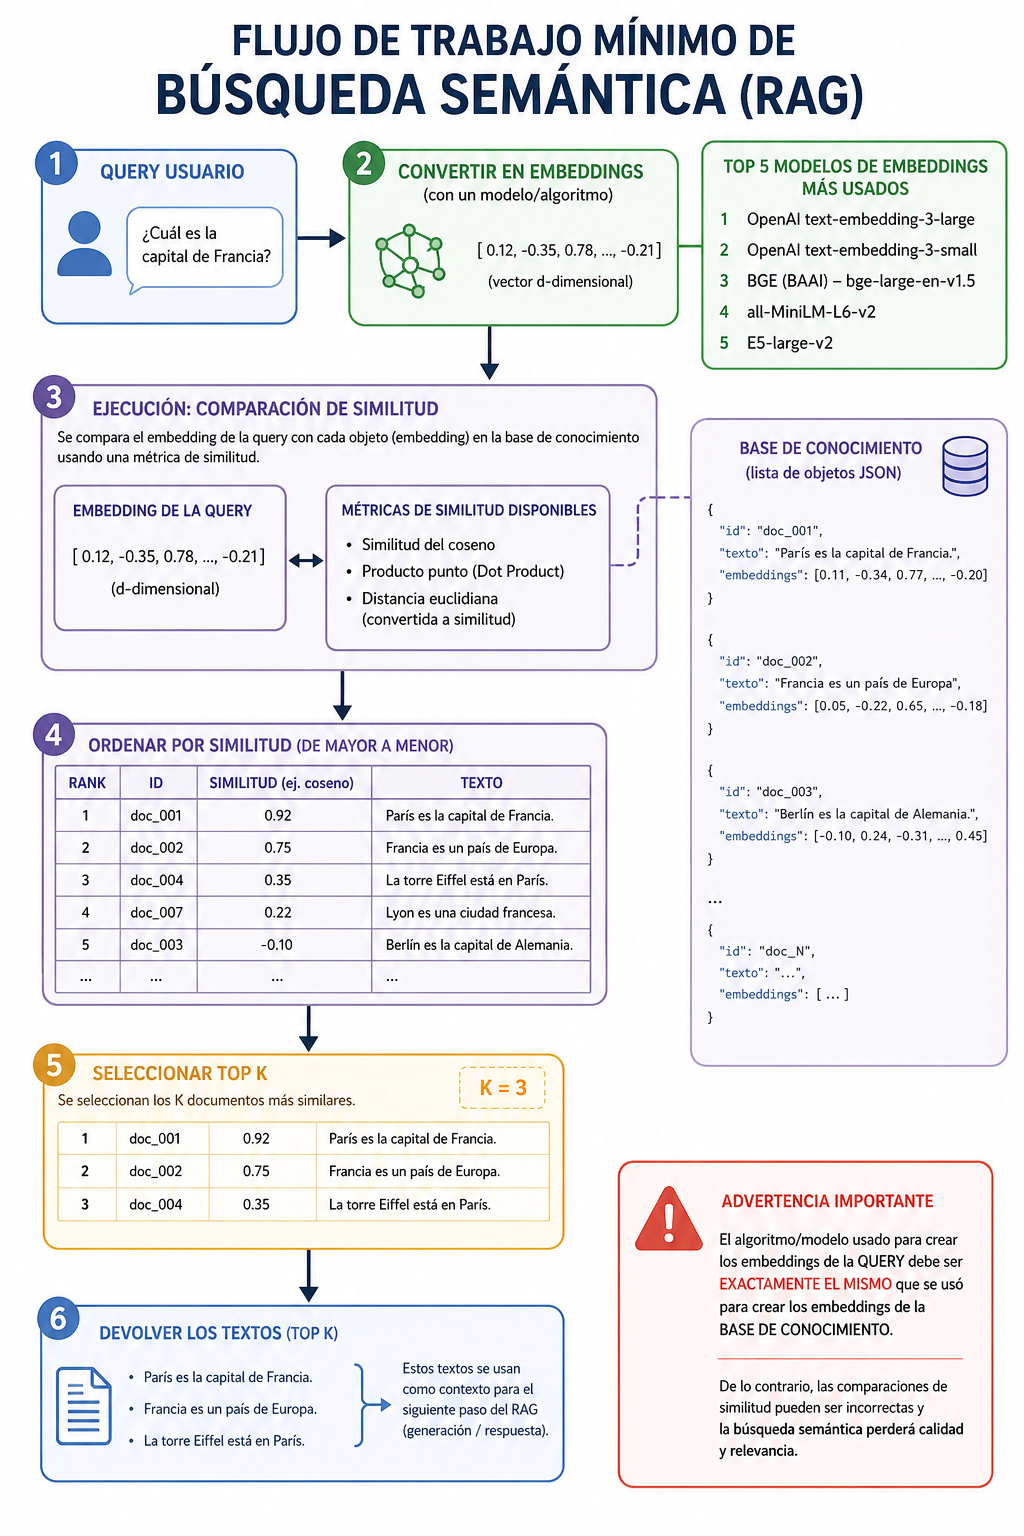

En un entorno mas similar a uno real las estructuras de datos se complejizan un poco mas y cada objeto JSON tiene otros datos incluidos que los denominamos metadatos.

Estos metadatos sirven para otras tareas de ordenado, filtrado, e incluso indexado.


```
{
  "id": 1,
  "texto": "...",
  "embedding": [...],
  "metadata": {
    "tipo": "factura",
    "cliente": "Juan Perez"
  }
}

```

La estructura de datos en general toma esta forma que vimos, luego el soporte en el cual se guarde es totalmente variable y dependera del uso que le demos, se podria guardar solo en memoria, podemos mantenerlo como objeto persistente en un json o en un texto plano. Esto ya depende mucho de que es lo que queremos hacer, si bien en un entorno productivo muy rara vez podriamos ver los datos registrados con estas tecnicas, si podriamos utilizarlas si nuestra base de conocimiento es relativamente reducida y no tiene sentido el montaje de un motor de bases de datos vectorial (con todo lo que eso implica).




Vamos a ver un codigo completo donde practicamos todos los pasos que vimos anteriormente

[02_Ejemplo_RAG_MINIMO](https://colab.research.google.com/drive/1jJuc3-3SXo2Fl5HqNjsFpXbuaxZo_HuY?usp=sharing)